# Chapter 4: Thresholds, Calibration and the Safety Operating Point

Companion notebook for *Practical AI Safety from First Principles*, Chapter 4.

Chapter 3 gave us a fitted classifier that turns a prompt-response pair into a continuous unsafe score. That notebook quietly used the default 0.5 cutoff to turn the score into a decision. This chapter treats that cutoff as the thing to be designed, not assumed. We separate scoring from decision-making, sweep the threshold to see precision and recall move, build precision-recall and ROC curves, check whether the model's probabilities are actually calibrated, calibrate them if not, and turn all of that into an explicit, reproducible safety policy rather than a single number.

By the end we will have: a clean fit/calibration/test split, threshold sweeps and PR/ROC curves, cost-sensitive and constraint-based threshold selection, reliability diagrams plus Brier score, log loss and expected calibration error, Platt and isotonic calibration compared on held-out data, a three-way allow/review/block policy, and a final test-set evaluation of the whole package (model, calibrator, threshold) that was decided before the test set was ever touched.

## 4.1 From Scores to Operating Decisions

### Loading the Chapter 3 Classifier and Data

In [1]:
# This notebook needs the Chapter 2 processed split and the Chapter 3 fitted pipeline.
# If either is missing (e.g. this notebook is run on its own after a fresh clone), we
# regenerate them here using the exact same procedure as those chapters, so this notebook
# stays runnable standalone.
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data/processed")
MODEL_DIR = Path("models")
TRAIN_PATH = DATA_DIR / "beavertails_train.parquet"
TEST_PATH = DATA_DIR / "beavertails_test.parquet"
MODEL_PATH = MODEL_DIR / "beavertails_tfidf_logreg.joblib"

if TRAIN_PATH.exists() and TEST_PATH.exists():
    train_df = pd.read_parquet(TRAIN_PATH)
    test_df = pd.read_parquet(TEST_PATH)
else:
    print("Processed split not found, regenerating it from BeaverTails (same steps as Chapter 2)...")
    from datasets import load_dataset
    from sklearn.model_selection import train_test_split

    dataset = load_dataset("PKU-Alignment/BeaverTails", split="30k_train")
    df = dataset.to_pandas()
    df["text"] = (
        "[PROMPT]\n" + df["prompt"].fillna("") +
        "\n\n[RESPONSE]\n" + df["response"].fillna("")
    )
    df["target"] = (~df["is_safe"]).astype(int)

    train_df, test_df = train_test_split(
        df[["prompt", "response", "text", "target"]],
        test_size=0.20, stratify=df["target"], random_state=42,
    )
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    train_df.to_parquet(TRAIN_PATH, index=False)
    test_df.to_parquet(TEST_PATH, index=False)

import joblib

if MODEL_PATH.exists():
    safety_clf = joblib.load(MODEL_PATH)
else:
    print("Chapter 3 model not found, refitting the baseline pipeline (same steps as Chapter 3)...")
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import Pipeline

    safety_clf = Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True, strip_accents="unicode", ngram_range=(1, 2),
            min_df=3, max_df=0.98, sublinear_tf=True, max_features=100_000,
        )),
        ("classifier", LogisticRegression(
            C=1.0, max_iter=1000, solver="liblinear", random_state=42,
        )),
    ])
    safety_clf.fit(train_df["text"], train_df["target"])
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump(safety_clf, MODEL_PATH)

print("train:", train_df.shape, "test:", test_df.shape)

train: (21748, 4) test: (5438, 4)


In [2]:
# Confirm the default predict() behaviour: an implicit 0.5 threshold on the unsafe score
X_test = test_df["text"]
y_test = test_df["target"]

p_test = safety_clf.predict_proba(X_test)[:, 1]
y_default = (p_test >= 0.5).astype(int)

print(p_test[:10])
print(y_default[:10])

[0.28861747 0.50146908 0.89573432 0.7331428  0.21822787 0.16843094
 0.29691063 0.79604518 0.77065835 0.91189082]
[0 1 1 1 0 0 0 1 1 1]


**The threshold has a meaning in log-odds space.** Because our classifier is logistic regression, a probability threshold also corresponds to a threshold on the linear score *z* it computes before the sigmoid. Recall that the odds of an event with probability *p* are `p / (1 - p)`, and the log-odds (the logit) are `log(p / (1 - p))`. The sigmoid and logit functions are inverses, so choosing a probability threshold τ is equivalent to choosing a linear-score threshold `z >= logit(τ)`.

At the familiar threshold τ = 0.5, `logit(0.5) = 0`, so the model predicts unsafe whenever the linear score is at least zero. If we lower the probability threshold to 0.2, the equivalent log-odds threshold is about -1.386: the classifier now requires much less evidence before predicting the unsafe class. If we raise the threshold to 0.8, the equivalent log-odds threshold is about +1.386.

In [3]:
from scipy.special import logit

for tau in [0.5, 0.2, 0.8]:
    print(f"logit({tau}) = {logit(tau):.3f}")

logit(0.5) = 0.000
logit(0.2) = -1.386
logit(0.8) = 1.386


There is a problem with tuning a threshold here: if we sweep thresholds against `y_test` and pick whatever looks best, the test set stops being an independent final check, we have optimised a system decision against it. That is evaluation leakage even though the model weights never saw the test labels.

We need a third partition. The **fit** set trains the model. The **calibration** set is used to choose thresholds and fit calibration mappings. The **test** set stays untouched until every decision is finalised.

## 4.2 Measuring Threshold Trade-offs

### Creating a Calibration Split Without Touching the Test Set

In [4]:
from sklearn.model_selection import train_test_split

fit_df, cal_df = train_test_split(
    train_df, test_size=0.20, stratify=train_df["target"], random_state=42,
)

print("fit :", fit_df.shape)
print("cal :", cal_df.shape)
print("test:", test_df.shape)

fit : (17398, 4)
cal : (4350, 4)
test: (5438, 4)


We now recreate the Chapter 3 classifier exactly. The vocabulary rules, TF-IDF settings, regularisation strength, solver and absence of class weighting all remain unchanged, so a threshold or calibration decision made in this chapter cannot be silently explained by a different underlying model.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

base_clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True, strip_accents="unicode", ngram_range=(1, 2),
        min_df=3, max_df=0.98, sublinear_tf=True, max_features=100_000,
    )),
    ("logreg", LogisticRegression(
        C=1.0, max_iter=1_000, solver="liblinear", random_state=42,
    )),
])

base_clf = base_clf.fit(fit_df["text"], fit_df["target"])

In [6]:
p_cal = base_clf.predict_proba(cal_df["text"])[:, 1]
y_cal = cal_df["target"].to_numpy()

### Before Choosing a Threshold, Look at the Score Distribution

If the classifier separates the classes well, safe and unsafe scores should look different. Real data usually has an overlap region: ambiguous labels, legitimate technical discussion that shares vocabulary with harmful requests, euphemistic content, or short responses with little evidence. Threshold selection is really a decision about what to do with that overlap.

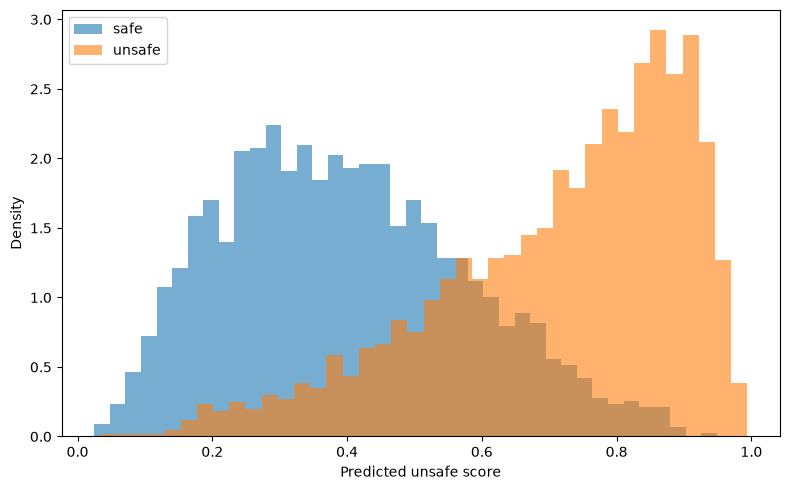

In [7]:
import matplotlib.pyplot as plt

safe_scores = p_cal[y_cal == 0]
unsafe_scores = p_cal[y_cal == 1]

plt.figure(figsize=(8, 5))
plt.hist(safe_scores, bins=40, alpha=0.6, label="safe", density=True)
plt.hist(unsafe_scores, bins=40, alpha=0.6, label="unsafe", density=True)
plt.xlabel("Predicted unsafe score")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
import numpy as np

for name, scores in {"safe": safe_scores, "unsafe": unsafe_scores}.items():
    q = np.quantile(scores, [0.05, 0.25, 0.50, 0.75, 0.95])
    print(name, q)

safe [0.13015189 0.25868855 0.38233385 0.51954185 0.72136998]
unsafe [0.3474855  0.60277263 0.76085603 0.86474005 0.94080449]


### Sweeping the Threshold

Instead of accepting 0.5, we evaluate the classifier at many thresholds and watch precision, recall, specificity, false-positive rate and false-negative rate move.

In [9]:
import pandas as pd
from sklearn.metrics import confusion_matrix

def metrics_at_threshold(y_true, scores, threshold):
    pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    fnr = fn / (fn + tp) if (fn + tp) else 0.0

    return {
        "threshold": threshold, "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "precision": precision, "recall": recall, "specificity": specificity,
        "fpr": fpr, "fnr": fnr,
    }

thresholds = np.linspace(0.05, 0.95, 19)
threshold_table = pd.DataFrame([metrics_at_threshold(y_cal, p_cal, t) for t in thresholds])
threshold_table

,threshold,tp,fp,fn,tn,precision,recall,specificity,fpr,fnr
0,0.05,2492,1853,1,4,0.573533,0.999599,0.002154,0.997846,0.000401
1,0.10,2490,1816,3,41,0.578263,0.998797,0.022079,0.977921,0.001203
2,0.15,2486,1730,7,127,0.589658,0.997192,0.068390,0.931610,0.002808
3,0.20,2465,1595,28,262,0.607143,0.988769,0.141088,0.858912,0.011231
4,0.25,2439,1423,54,434,0.631538,0.978339,0.233710,0.766290,0.021661
5,0.30,2409,1228,84,629,0.662359,0.966306,0.338718,0.661282,0.033694
6,0.35,2362,1041,131,816,0.694093,0.947453,0.439418,0.560582,0.052547
7,0.40,2306,864,187,993,0.727445,0.924990,0.534733,0.465267,0.075010
8,0.45,2237,677,256,1180,0.767673,0.897312,0.635433,0.364567,0.102688
9,0.50,2137,519,356,1338,0.804593,0.857200,0.720517,0.279483,0.142800


As the threshold drops, more examples get called unsafe: recall generally rises and precision generally falls. As it rises, the opposite generally happens. "Generally" is the operative word, metrics do not have to move monotonically in every finite-sample step, which is exactly why we calculate this instead of relying on intuition.

### Watching the Confusion Matrix Move

In [10]:
for threshold in [0.25, 0.50, 0.75]:
    row = metrics_at_threshold(y_cal, p_cal, threshold)
    print("\nthreshold:", threshold)
    print(row)


threshold: 0.25
{'threshold': 0.25, 'tp': np.int64(2439), 'fp': np.int64(1423), 'fn': np.int64(54), 'tn': np.int64(434), 'precision': np.float64(0.6315380631796996), 'recall': np.float64(0.9783393501805054), 'specificity': np.float64(0.23371028540656974), 'fpr': np.float64(0.7662897145934303), 'fnr': np.float64(0.021660649819494584)}

threshold: 0.5
{'threshold': 0.5, 'tp': np.int64(2137), 'fp': np.int64(519), 'fn': np.int64(356), 'tn': np.int64(1338), 'precision': np.float64(0.8045933734939759), 'recall': np.float64(0.857200160449258), 'specificity': np.float64(0.7205169628432956), 'fpr': np.float64(0.27948303715670436), 'fnr': np.float64(0.14279983955074207)}

threshold: 0.75
{'threshold': 0.75, 'tp': np.int64(1313), 'fp': np.int64(65), 'fn': np.int64(1180), 'tn': np.int64(1792), 'precision': np.float64(0.9528301886792453), 'recall': np.float64(0.5266746891295627), 'specificity': np.float64(0.9649973074851912), 'fpr': np.float64(0.03500269251480883), 'fnr': np.float64(0.473325310870

Lowering the threshold does not merely "increase recall", it stops more users, some genuinely unsafe, some legitimate users whose requests happen to resemble unsafe examples. Raising it does not merely "increase precision", it lets more borderline requests through, some legitimate, some exactly the unsafe cases the guardrail exists to catch.

### Precision and Recall as a Curve Rather Than Two Numbers

Every point on a precision-recall curve corresponds to a different threshold for the *same* fitted model. Moving the threshold slides us along this curve. Improving the model moves the curve itself, which is why future model comparisons should look at achievable trade-off curves, not just one operating point.

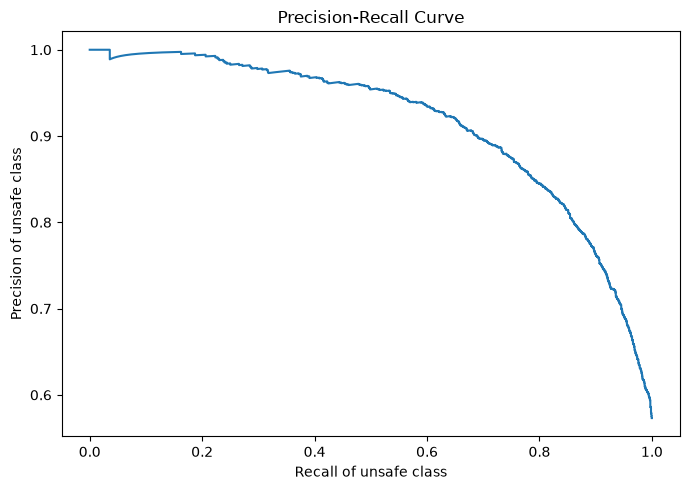

In [11]:
from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresholds = precision_recall_curve(y_cal, p_cal)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall of unsafe class")
plt.ylabel("Precision of unsafe class")
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

### Average Precision

In [12]:
from sklearn.metrics import average_precision_score

ap = average_precision_score(y_cal, p_cal)
print("Average precision:", ap)

Average precision: 0.9143011050937069


Average precision is threshold-independent: it scores the ranking the model induces, not one chosen operating point. It tells us what the model is capable of. It does not choose the threshold for us, two teams with the same average precision can deploy very differently depending on their tolerance for each kind of error.

### ROC Curves and Why They Can Mislead on Rare-Event Safety Problems

ROC-AUC has a clean interpretation (roughly, the probability a random positive outscores a random negative), but its x-axis, false-positive rate, is computed against the number of actual negatives. When negatives vastly outnumber positives, a "small" false-positive rate can still flood a review queue.

ROC-AUC: 0.8813204706079554


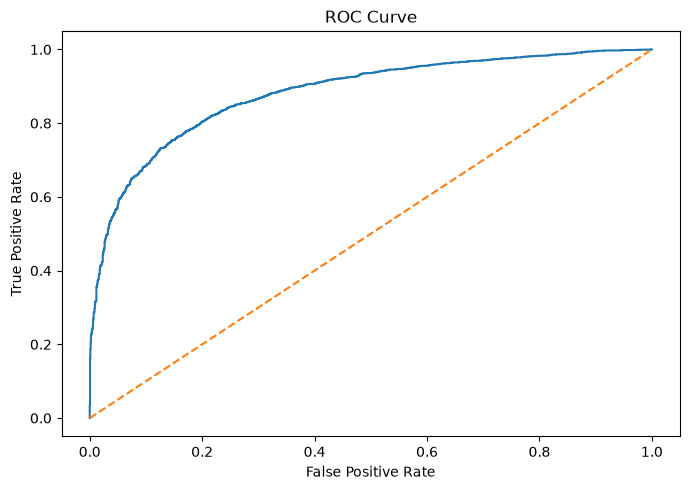

In [13]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, roc_thresholds = roc_curve(y_cal, p_cal)
roc_auc = roc_auc_score(y_cal, p_cal)
print("ROC-AUC:", roc_auc)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.tight_layout()
plt.show()

In [14]:
# The book's worked illustration: out of 1,000,000 requests, only 1,000 are unsafe.
# A classifier with 90% recall and a seemingly tiny 1% false-positive rate still
# produces a review queue that is mostly false alarms.
total, unsafe_count = 1_000_000, 1_000
safe_count = total - unsafe_count

tp_illustration = 0.90 * unsafe_count
fp_illustration = 0.01 * safe_count
precision_illustration = tp_illustration / (tp_illustration + fp_illustration)

print(f"TP={tp_illustration:.0f}, FP={fp_illustration:.0f}, precision={precision_illustration:.3f}")

TP=900, FP=9990, precision=0.083


## 4.3 Choosing the Safety Operating Point

### Choosing an Operating Point with F-beta

F1 weights precision and recall equally. In safety work we often do not want that. F-beta with beta > 1 favours recall; beta < 1 favours precision.

In [15]:
from sklearn.metrics import fbeta_score

def fbeta_at_threshold(y_true, scores, threshold, beta):
    pred = (scores >= threshold).astype(int)
    return fbeta_score(y_true, pred, beta=beta, zero_division=0)

candidate_thresholds = np.linspace(0.05, 0.95, 181)

f2_scores = [fbeta_at_threshold(y_cal, p_cal, t, beta=2) for t in candidate_thresholds]

best_index = int(np.argmax(f2_scores))
best_threshold_f2 = candidate_thresholds[best_index]

print("Best F2 threshold:", best_threshold_f2)
print("Best F2 score:", f2_scores[best_index])

Best F2 threshold: 0.32499999999999996
Best F2 score: 0.8857946970819138


Maximising F2 is still a modelling choice, it quietly embeds a 4:1 preference for recall over precision. It does not represent the real cost of a harmful miss versus an annoying block. If we have actual cost estimates, we can be more explicit.

### Threshold Selection as Expected Cost

In [16]:
def cost_at_threshold(y_true, scores, threshold, cost_fp=1.0, cost_fn=5.0):
    pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    total_cost = cost_fp * fp + cost_fn * fn
    return total_cost / len(y_true)

costs = [cost_at_threshold(y_cal, p_cal, t, cost_fp=1.0, cost_fn=5.0) for t in candidate_thresholds]

best_index = int(np.argmin(costs))
best_threshold_cost = candidate_thresholds[best_index]

print("Minimum-cost threshold:", best_threshold_cost)
print("Observed cost per example:", costs[best_index])

Minimum-cost threshold: 0.32499999999999996
Observed cost per example: 0.3777011494252874


The values 1 and 5 are illustrative. What matters is the structure: once a false negative is treated as five times as costly as a false positive, the optimum shifts towards recall. Real safety costs are rarely available as clean numbers, but making the assumption explicit and reproducible beats picking a threshold by habit.

### Sensitivity Analysis Instead of Pretending the Costs Are Known

In [17]:
cost_ratios = [1, 2, 3, 5, 10, 20]
rows = []

for cost_fn in cost_ratios:
    threshold_costs = [
        cost_at_threshold(y_cal, p_cal, t, cost_fp=1.0, cost_fn=cost_fn)
        for t in candidate_thresholds
    ]
    i = int(np.argmin(threshold_costs))
    rows.append({"cost_fn": cost_fn, "threshold": candidate_thresholds[i], "cost": threshold_costs[i]})

sensitivity_df = pd.DataFrame(rows)
sensitivity_df

,cost_fn,threshold,cost
0,1,0.520,0.195632
1,2,0.455,0.273103
2,3,0.390,0.320690
3,5,0.325,0.377701
4,10,0.170,0.407126
5,20,0.160,0.423908


If the chosen threshold barely moves across a wide range of plausible cost ratios, the decision is robust. If it swings wildly, that itself is important information: the policy is highly sensitive to a value nobody can actually measure precisely.

### A Constraint Can Be More Useful Than a Weighted Metric

Rather than a cost function, a deployment requirement is often easier to express as a constraint: recall must be at least 95%, and among thresholds meeting that bar, pick the one with the best precision.

In [18]:
candidate_rows = pd.DataFrame([metrics_at_threshold(y_cal, p_cal, t) for t in candidate_thresholds])

feasible = candidate_rows[candidate_rows["recall"] >= 0.95]

if len(feasible):
    chosen = feasible.sort_values("precision", ascending=False).iloc[0]
    print(chosen)

threshold         0.345000
tp             2371.000000
fp             1064.000000
fn              122.000000
tn              793.000000
precision         0.690247
recall            0.951063
specificity       0.427033
fpr               0.572967
fnr               0.048937
Name: 59, dtype: float64


This is often easier to communicate than an implicit cost ratio: the safety policy requires at least 95% recall on the validation benchmark, and this is the least disruptive threshold that satisfies it. We still need to ask whether 95% and this benchmark represent production, but the rule itself is explicit.

### Threshold Tuning Does Not Improve Ranking

If the model scores an unsafe example at 0.82 and a safe example at 0.91, no threshold gets both right: below 0.82 both are called unsafe, between 0.82 and 0.91 the unsafe one becomes "safe" and the safe one stays "unsafe", above 0.91 both are called safe. The problem is not the threshold, it is that the model ranked the safe example above the unsafe one. Metrics like ROC-AUC and average precision measure this ranking quality independently of any single cutoff. If they are poor, no amount of threshold tuning fixes it, that needs better data, features, or a better model.

## 4.4 Calibration and Probability Quality

### Discrimination and Calibration Are Different Properties

A model can rank examples perfectly (every unsafe example scores above every safe one) while still being miscalibrated, if examples scored around 0.8 are only unsafe 55% of the time, 0.8 is not behaving like an 80% probability. A well-calibrated model should satisfy, approximately, P(unsafe | score = s) is about s for the relevant range of s. This matters whenever a score is used as a quantity rather than just an ordering: routing decisions, combining multiple guardrails, or letting an agent act automatically below one risk level.

### Reliability Diagrams

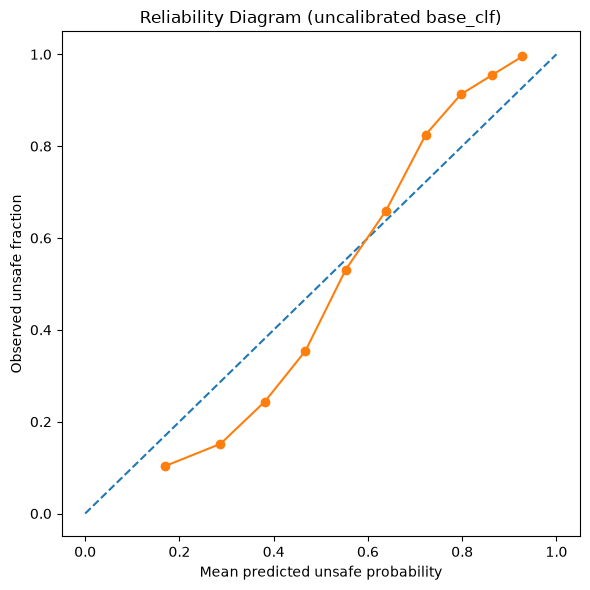

In [19]:
from sklearn.calibration import calibration_curve

frac_pos, mean_pred = calibration_curve(y_cal, p_cal, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--")
plt.plot(mean_pred, frac_pos, marker="o")
plt.xlabel("Mean predicted unsafe probability")
plt.ylabel("Observed unsafe fraction")
plt.title("Reliability Diagram (uncalibrated base_clf)")
plt.tight_layout()
plt.show()

Points below the diagonal mean the model is overconfident about "unsafe", above it, underconfident. This is a diagnostic, not a proof: too few bins hides structure, too many makes each bin noisy.

### The Brier Score

In [20]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_cal, p_cal)
print("Brier score:", brier)

Brier score: 0.14680067061069774


Brier score is mean squared error between predicted probability and outcome, lower is better. It mixes calibration with discrimination (sometimes called resolution), a model that separates the classes better can improve its Brier score even with an imperfect calibration curve.

### Log Loss Punishes Confident Mistakes Even More Strongly

In [21]:
from sklearn.metrics import log_loss

ll = log_loss(y_cal, p_cal)
print("Log loss:", ll)

Log loss: 0.4576463460300791


A confidently wrong score is especially dangerous in a safety system because downstream logic may treat it as strong evidence. A genuinely unsafe example scored at 0.001 can make a risk-routing system treat it as almost certainly safe.

### Expected Calibration Error

In [22]:
def expected_calibration_error(y_true, scores, n_bins=10):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(scores, edges[1:-1], right=True)

    ece = 0.0
    for b in range(n_bins):
        mask = bin_ids == b
        if not np.any(mask):
            continue
        mean_score = scores[mask].mean()
        frac_positive = y_true[mask].mean()
        weight = mask.mean()
        ece += weight * abs(frac_positive - mean_score)
    return ece

ece = expected_calibration_error(y_cal, p_cal, n_bins=10)
print("ECE:", ece)

ECE: 0.08812064578437334


ECE depends on the binning choice and compresses calibration into one number, it can hide a model that is well calibrated overall but badly overconfident right around the operating threshold. Treat it as one diagnostic among several.

### Why Logistic Regression Is Not Automatically Calibrated

`predict_proba()` existing does not mean the numbers are trustworthy probabilities. Text features are high-dimensional and correlated, regularisation changes coefficient estimates, the logistic functional form may not match the true conditional relationship, the benchmark prevalence may differ from deployment, and label noise or ambiguity limits the meaning of the target itself. Even without class weighting, a probability-like output should be treated as an empirical claim rather than a guarantee: the correct question is whether examples receiving a score near *p* are actually positive at roughly rate *p* on data that was not used to fit the probability mapping. This applies to neural networks, boosted trees, SVMs and LLM-based judges too, not just logistic regression.

### Platt-Style Sigmoid Calibration from First Principles

In [23]:
# Use the model's raw linear score (pre-sigmoid) as the input to a one-dimensional calibrator
s_cal = base_clf.decision_function(cal_df["text"])

In [24]:
platt = LogisticRegression()
platt.fit(s_cal.reshape(-1, 1), y_cal)

def predict_platt_probability(texts):
    raw_score = base_clf.decision_function(texts)
    return platt.predict_proba(raw_score.reshape(-1, 1))[:, 1]

This second logistic model does not relearn text classification, it learns how the base model's raw score maps onto empirical probabilities on the calibration distribution. Because the mapping is monotonic, ROC-AUC and average precision stay essentially unchanged, calibration changes what the score *means*, not the ranking that produced it.

### Isotonic Calibration

In [25]:
from sklearn.isotonic import IsotonicRegression

isotonic = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds="clip")
isotonic.fit(s_cal, y_cal)

def predict_isotonic_probability(texts):
    raw_score = base_clf.decision_function(texts)
    return isotonic.predict(raw_score)

Isotonic regression fits a flexible monotonic mapping instead of assuming a sigmoid shape. That flexibility is also its risk, with too little calibration data it can overfit into a noisy staircase. We should compare methods on held-out data rather than assume the more flexible one wins.

### Comparing Calibration Methods Without Touching the Test Set Too Early

Evaluating a calibrator on the same data used to fit it is optimistic, especially for isotonic regression. We split the calibration partition itself into a piece to fit the calibrators and a piece to evaluate them, keeping the test set completely out of this.

In [26]:
cal_fit_df, cal_eval_df = train_test_split(
    cal_df, test_size=0.50, stratify=cal_df["target"], random_state=43,
)

s_cal_fit = base_clf.decision_function(cal_fit_df["text"])
y_cal_fit = cal_fit_df["target"].to_numpy()

platt_cmp = LogisticRegression()
platt_cmp.fit(s_cal_fit.reshape(-1, 1), y_cal_fit)

isotonic_cmp = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds="clip")
isotonic_cmp.fit(s_cal_fit, y_cal_fit)

s_cal_eval = base_clf.decision_function(cal_eval_df["text"])
y_cal_eval = cal_eval_df["target"].to_numpy()

p_raw_eval = base_clf.predict_proba(cal_eval_df["text"])[:, 1]
p_platt_eval = platt_cmp.predict_proba(s_cal_eval.reshape(-1, 1))[:, 1]
p_isotonic_eval = isotonic_cmp.predict(s_cal_eval)

calibration_comparison = []
for name, p in [("raw", p_raw_eval), ("platt", p_platt_eval), ("isotonic", p_isotonic_eval)]:
    calibration_comparison.append({
        "method": name,
        "brier": brier_score_loss(y_cal_eval, p),
        "log_loss": log_loss(y_cal_eval, p),
        "ece": expected_calibration_error(y_cal_eval, p, n_bins=10),
    })

calibration_comparison_df = pd.DataFrame(calibration_comparison)
calibration_comparison_df

,method,brier,log_loss,ece
0,raw,0.147953,0.459983,0.085080
1,platt,0.139668,0.432230,0.027372
2,isotonic,0.140503,0.432981,0.025216


Once a calibration method is chosen this way, it gets refit on the *full* calibration partition (not just the half used for this comparison) before it is used against the test set.

### Calibration Can Change the Best Numerical Threshold Without Changing the Ranking

If the uncalibrated model needs a threshold of 0.27 to hit a target recall, the calibrated version of the same ranking might need 0.61 to hit the same operating point. Nothing strange has happened, the probability scale changed, not the ordering. This is why a deployed threshold is meaningless without the exact model and calibration version that produced the scores, all three (model, calibration, threshold) form one operational package.

## 4.5 From Model Scores to Operational Policy

### Base Rates Change Precision Even When the Model Does Not Change

In [27]:
def precision_from_rates(tpr, fpr, prevalence):
    numerator = tpr * prevalence
    denominator = numerator + fpr * (1.0 - prevalence)
    return numerator / denominator

for prevalence in [0.50, 0.10, 0.01, 0.001]:
    p = precision_from_rates(tpr=0.95, fpr=0.02, prevalence=prevalence)
    print(prevalence, p)

0.5 0.979381443298969
0.1 0.8407079646017699
0.01 0.3242320819112628
0.001 0.04538939321548017


Same true-positive rate, same false-positive rate, wildly different precision, purely because the underlying prevalence changed. A classifier can look extremely precise on a balanced benchmark and produce a noisy alert stream in production where unsafe traffic is genuinely rare. Under the stronger "prior probability shift" assumption (only the class prior changes, the conditional feature distributions stay stable), probability estimates can sometimes be corrected for a new prior, but real production drift usually changes more than just the prior, so this correction is not a general fix for distribution shift. Chapter 5 picks this up properly.

### A Binary Decision Is Not Our Only Option

Real systems often benefit from a third action: do not decide automatically. Below a low threshold, allow. Above a high threshold, block. In between, route to a stronger model, a deterministic rule, or a human reviewer.

In [28]:
def safety_action(p_unsafe, low=0.25, high=0.75):
    if p_unsafe < low:
        return "allow"
    if p_unsafe < high:
        return "review"
    return "block"

In [29]:
def assign_actions(scores, low, high):
    actions = np.empty(len(scores), dtype=object)
    actions[scores < low] = "allow"
    actions[(scores >= low) & (scores < high)] = "review"
    actions[scores >= high] = "block"
    return actions

actions = assign_actions(p_cal, low=0.25, high=0.75)
print(pd.Series(actions).value_counts(normalize=True))

review    0.571034
block     0.316782
allow     0.112184
Name: proportion, dtype: float64


Introducing a review band creates a new constraint: reviewers have finite capacity. If the review team can handle at most 2% of traffic, the review band has to be sized to respect that, not just to look good on a plot.

In [30]:
review_rate = (pd.Series(actions) == "review").mean()
print(f"Review rate at (0.25, 0.75): {review_rate:.2%}")
print("Fits within a 2% review capacity:", review_rate <= 0.02)

Review rate at (0.25, 0.75): 57.10%
Fits within a 2% review capacity: False


### Different Thresholds for Different Harm Categories, and Governance

BeaverTails also carries a multilabel harm taxonomy. Nothing stops us from giving each category its own threshold, an especially severe category could justify a lower one, a category prone to legitimate technical overlap might need a different operating point. But every extra threshold makes the system harder to validate, monitor and explain, and can create inconsistency across categories. The rule of thumb: use the simplest decision policy that captures the meaningful asymmetries and can still be properly validated. A threshold change is a policy change, not just a hyperparameter tweak, so it belongs in a versioned, reviewable configuration alongside the model and calibration version.

### Storing the Policy as Configuration

In [31]:
CONFIG_DIR = Path("config")
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

# Illustrative draft: this is the exploratory recall >= 95% threshold from section 4.14,
# selected against raw, uncalibrated scores on the full calibration set. It shows what the
# policy file looks like as a reviewable artifact. Section 4.34 recomputes and freezes the
# real threshold on calibrated, held-out scores before the test set is touched, and
# overwrites this file with that final value.
draft_threshold = float(chosen["threshold"])

policy_text = f"""model:
  path: models/beavertails_tfidf_logreg_ch4.joblib
  version: chapter4-v1

calibration:
  method: platt
  path: models/beavertails_platt_ch4.joblib

policy:
  unsafe_label: 1
  block_at_or_above: {draft_threshold:.4f}

selection:
  calibration_split_seed: 42
  minimum_unsafe_recall: 0.95
"""

(CONFIG_DIR / "beavertails_safety_policy_ch4.yaml").write_text(policy_text)
print(policy_text)

model:
  path: models/beavertails_tfidf_logreg_ch4.joblib
  version: chapter4-v1

calibration:
  method: platt
  path: models/beavertails_platt_ch4.joblib

policy:
  unsafe_label: 1
  block_at_or_above: 0.3450

selection:
  calibration_split_seed: 42
  minimum_unsafe_recall: 0.95



## 4.6 Final Evaluation, Uncertainty and Monitoring

### Finalising the Calibration and Threshold Before the Test Set

We decided the probability representation (Platt calibration, section 4.22), the operating policy (a single threshold), and the selection criterion (recall >= 95%, section 4.14) using only the fit and calibration partitions. But the section 4.14 threshold was chosen against raw, uncalibrated scores on the full calibration set, and section 4.25 already warned us that calibration can change the numerical threshold needed to hit a target recall without changing the ranking. So before we touch the test set, we re-run the same recall >= 95% constraint against Platt-calibrated scores on the held-out `cal_eval_df`, and freeze that as the real threshold. Only then do we touch the test set, once.

In [32]:
# base_clf is already fitted on fit_df; platt is already fitted on the full cal_df (section 4.22)
s_cal_eval = base_clf.decision_function(cal_eval_df["text"])
p_cal_eval_calibrated = platt.predict_proba(s_cal_eval.reshape(-1, 1))[:, 1]
y_cal_eval_final = cal_eval_df["target"].to_numpy()

candidate_rows_final = pd.DataFrame([
    metrics_at_threshold(y_cal_eval_final, p_cal_eval_calibrated, t)
    for t in candidate_thresholds
])
feasible_final = candidate_rows_final[candidate_rows_final["recall"] >= 0.95].copy()

if feasible_final.empty:
    raise RuntimeError("No threshold satisfies the minimum recall requirement.")

chosen_final = feasible_final.sort_values(
    ["precision", "threshold"], ascending=[False, False],
).iloc[0]
chosen_threshold = float(chosen_final["threshold"])

print("Final calibrated threshold (recall >= 95% on cal_eval_df):", chosen_threshold)
print(chosen_final)

# Freeze the policy config with this final, calibrated threshold before evaluating on the test set.
policy_text = f"""model:
  path: models/beavertails_tfidf_logreg_ch4.joblib
  version: chapter4-v1

calibration:
  method: platt
  path: models/beavertails_platt_ch4.joblib

policy:
  unsafe_label: 1
  block_at_or_above: {chosen_threshold:.4f}

selection:
  calibration_split_seed: 42
  minimum_unsafe_recall: 0.95
"""
(CONFIG_DIR / "beavertails_safety_policy_ch4.yaml").write_text(policy_text)
print(policy_text)

s_test = base_clf.decision_function(test_df["text"])
p_test_calibrated = platt.predict_proba(s_test.reshape(-1, 1))[:, 1]

final_pred = (p_test_calibrated >= chosen_threshold).astype(int)

Final calibrated threshold (recall >= 95% on cal_eval_df): 0.195
threshold         0.195000
tp             1187.000000
fp              574.000000
fn               60.000000
tn              354.000000
precision         0.674049
recall            0.951885
specificity       0.381466
fpr               0.618534
fnr               0.048115
Name: 29, dtype: float64
model:
  path: models/beavertails_tfidf_logreg_ch4.joblib
  version: chapter4-v1

calibration:
  method: platt
  path: models/beavertails_platt_ch4.joblib

policy:
  unsafe_label: 1
  block_at_or_above: 0.1950

selection:
  calibration_split_seed: 42
  minimum_unsafe_recall: 0.95



In [33]:
from sklearn.metrics import classification_report

print(classification_report(
    test_df["target"], final_pred, target_names=["safe", "unsafe"], zero_division=0,
))
print(confusion_matrix(test_df["target"], final_pred))
print("Average precision:", average_precision_score(test_df["target"], p_test_calibrated))
print("ROC-AUC:", roc_auc_score(test_df["target"], p_test_calibrated))
print("Brier:", brier_score_loss(test_df["target"], p_test_calibrated))
print("Log loss:", log_loss(test_df["target"], p_test_calibrated))

              precision    recall  f1-score   support

        safe       0.87      0.38      0.53      2321
      unsafe       0.68      0.96      0.79      3117

    accuracy                           0.71      5438
   macro avg       0.77      0.67      0.66      5438
weighted avg       0.76      0.71      0.68      5438

[[ 892 1429]
 [ 134 2983]]
Average precision: 0.908399015138546
ROC-AUC: 0.8738996734699858
Brier: 0.14261075400008083
Log loss: 0.4402103605403285


If test performance came out materially worse than the calibration performance, the correct response is to investigate, not to quietly move the threshold until the numbers look better. The discipline of leaving the test set alone is valuable precisely because it can tell us something we would rather not hear.

In [34]:
# Save the final chapter 4 artifacts: model, calibrator, policy config and a metrics report,
# matching the reproducibility checklist in section 4.39.
joblib.dump(base_clf, MODEL_DIR / "beavertails_tfidf_logreg_ch4.joblib")
joblib.dump(platt, MODEL_DIR / "beavertails_platt_ch4.joblib")

REPORTS_DIR = Path("reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
threshold_table.to_csv(REPORTS_DIR / "chapter4_threshold_table.csv", index=False)

print("Saved model, calibrator and threshold table.")

Saved model, calibrator and threshold table.


### Confidence Intervals Around an Operating Point

A reported recall of 0.9473 can look precise while hiding a much wider plausible range. Bootstrap resampling gives us that range directly from the test set.

In [35]:
from sklearn.metrics import recall_score

rng = np.random.default_rng(42)

def bootstrap_recall(y_true, y_pred, n_boot=2_000):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    values = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_b = y_true[idx]
        p_b = y_pred[idx]
        if y_b.sum() == 0:
            continue
        values.append(recall_score(y_b, p_b))
    return np.quantile(values, [0.025, 0.50, 0.975])

ci = bootstrap_recall(test_df["target"].to_numpy(), final_pred)
print("Recall 95% bootstrap interval [low, median, high]:", ci)

Recall 95% bootstrap interval [low, median, high]: [0.95003183 0.95714067 0.96410371]


In [36]:
import json

test_metrics = {
    "chosen_threshold": chosen_threshold,
    "average_precision": float(average_precision_score(test_df["target"], p_test_calibrated)),
    "roc_auc": float(roc_auc_score(test_df["target"], p_test_calibrated)),
    "brier": float(brier_score_loss(test_df["target"], p_test_calibrated)),
    "log_loss": float(log_loss(test_df["target"], p_test_calibrated)),
    "recall_bootstrap_ci": ci.tolist(),
}

(REPORTS_DIR / "chapter4_test_metrics.json").write_text(json.dumps(test_metrics, indent=2))
print(json.dumps(test_metrics, indent=2))

{
  "chosen_threshold": 0.195,
  "average_precision": 0.908399015138546,
  "roc_auc": 0.8738996734699858,
  "brier": 0.14261075400008083,
  "log_loss": 0.4402103605403285,
  "recall_bootstrap_ci": [
    0.9500318292970552,
    0.9571406715221658,
    0.9641037131882202
  ]
}


### The Threshold and the Calibration Can Drift Without Being Changed

A threshold of 0.60 that nobody has touched in six months can still mean something different today: user language shifts, attackers adapt phrasing, a new feature attracts a different population, an upstream model rewrites text before it reaches the classifier. Any of these can move the score distribution under an unchanged number. A useful early-warning signal is the positive prediction rate.

In [37]:
positive_prediction_rate = final_pred.mean()
print(f"Positive prediction rate on this test snapshot: {positive_prediction_rate:.2%}")
print("In production: track this over time. A sudden jump or drop with no policy change is a signal to investigate, not an answer by itself.")

Positive prediction rate on this test snapshot: 81.13%
In production: track this over time. A sudden jump or drop with no policy change is a signal to investigate, not an answer by itself.


The same logic applies to calibration: a score that meant 70% unsafe on validation data can quietly stop meaning that in production. Reliability diagrams and Brier/log-loss/ECE should be recomputed on recent labelled audit samples, not just once before launch.

### A Safety Score Is Not a Universal Probability of Harm

Even after calibration, a score of 0.82 is not "an 82% chance this causes real-world harm". It estimates something narrower: the probability that an example would receive the positive label under BeaverTails' annotation policy, conditional on this training and calibration process. Real-world harm depends on much more downstream: the user, the context, the surrounding system, whether an answer is acted on, and the controls around it. Calibration improves the statistical meaning of the score. It does not turn a narrow supervised-learning target into a universal measure of AI risk.

### Reproducibility Checklist

By this point the experiment should let another person reconstruct the exact operating point: the dataset version and split files, the random seeds for fit/calibration/evaluation, the exact TF-IDF and logistic-regression configuration, the class-weighting choice (none in the canonical Chapter 3/4 classifier), the calibration method and the data used to fit it, the threshold-selection criterion, the selected threshold, the final validation and test metrics, calibration diagnostics, software versions, and the saved model, calibrator and policy files. This notebook writes the model, calibrator, threshold table and test metrics to `models/`, `config/` and `reports/` for exactly that reason.

### Practical Exercise: Design Three Safety Operating Policies

Using `p_cal` and `y_cal` above, design three deliberately different policies for this same fitted model and report precision, recall, false-positive rate, false-negative rate, review rate (where relevant), and counts of false positives/negatives for each:

1. **Recall-first**: a threshold achieving at least 95% unsafe recall (section 4.14 already found one), report the resulting precision and how many legitimate examples it would block.
2. **Precision-first**: an operating point that keeps precision above a target you choose, report how many unsafe examples are consequently missed.
3. **Review-based**: low/high thresholds (section 4.28-4.30 gives the mechanism) that keep the review rate under a capacity constraint, for example 5%, while allowing/blocking the rest.

Then answer: in what kind of AI system would you deploy each policy, and what additional information would you need before making that call in production? There is no single correct threshold, the exercise is about connecting a statistical operating point to a real system consequence.

## 4.7 Where We Have Arrived

We turned a single classifier into a decision system: a score, a chosen threshold, a calibration mapping and an explicit policy, evaluated once on an untouched test set. We separated discrimination (does the model rank unsafe above safe) from calibration (do the numbers mean what they claim), and separated the model's ranking from the system's chosen operating point.

The classifier still assumes the future looks like BeaverTails. **Chapter 5** breaks that assumption on purpose: we will perturb the text, create deliberate distribution shift, and watch how quickly this carefully chosen operating point degrades against unfamiliar phrasings of the same underlying safety problems.